In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2,3"  
# os.environ["CUDA_VISIBLE_DEVICES"] = "2,3"  
from torch import nn


import numpy as np                                                                  
import torch                                          

                              
from transformers import AutoModelForCausalLM, AutoTokenizer  
from tqdm import tqdm
import matplotlib.pyplot as plt  
import torch.nn.functional as F
import gc
import re
import copy

import sys
sys.path.append('..')
import JCBScope_utils

# Move to GPU with optimal dtype
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = "cpu"


/home/jl3499/conda/LLM1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/jl3499/conda/LLM1/lib/python3.12/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [26]:
# mode = 'Temperature'
mode = 'Semantic'
# mode = 'gradient_x_input'
# mode = 'IG'
presence_list = [0.2,0.4,0.6,0.8,0.1]

In [27]:
# Load the tokenizer and model

# model_name = "meta-llama/Llama-3.2-1B"
model_name = "meta-llama/Llama-3.2-3B"
# model_name = "meta-llama/Llama-3.1-8B"
model_name_short = model_name.split("/")[-1]
if device == "cpu":
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(model_name)
    model = model.to(device)
else:
    tokenizer = AutoTokenizer.from_pretrained(model_name, device_map="auto")
    model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto")
    
embedding_layer = model.get_input_embeddings()
embed_device = embedding_layer.weight.device    

Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.19it/s]


In [31]:
front_pad = 0
back_pad = 0

top_k_fraction = 0.05
# top_k_fraction = 0.1
# top_k_fraction = 0.2



front_strip = 0
# random_ablation = True
random_ablation = False
# num_prompts = 1
num_prompts = 300


# Get special tokens if available
bos_token_id = tokenizer.bos_token_id if tokenizer.bos_token_id is not None else tokenizer.cls_token_id
eos_token_id = tokenizer.eos_token_id if tokenizer.eos_token_id is not None else tokenizer.sep_token_id


In [32]:
if (mode == 'Semantic') or (mode == 'IG'):
    unnormalized_logits = True
else:
    unnormalized_logits = False
    

def change_in_max_log_p_with_ablation(string, top_k_fraction=0.1, verbose=True, random_ablation = False):
    """Optimized: single model load, retain_graph=False, free logits before ablation."""
    input_ids_list = tokenizer(string, add_special_tokens=False)["input_ids"]
    if eos_token_id is not None:
        input_ids_list += [eos_token_id] * back_pad

    input_ids = torch.tensor([input_ids_list], dtype=torch.long).to(embed_device)
    attention_mask = torch.ones_like(input_ids, device=embed_device)
    seq_len = input_ids.size(1)

    decoded_tokens = [tokenizer.decode(tok.item(), skip_special_tokens=True) for tok in input_ids[0]]

    def get_token_indices_for_substring(tokens, substring):
        full = "".join(tokens)
        exclude_indices = set()
        start = 0
        while True:
            pos = full.find(substring, start)
            if pos == -1:
                break
            end = pos + len(substring)
            cumlen = 0
            for i, t in enumerate(tokens):
                tok_end = cumlen + len(t)
                if tok_end > pos and cumlen < end:
                    exclude_indices.add(i)
                cumlen = tok_end
            start = pos + 1
        return exclude_indices

    grad_idx = [idx for idx in range(front_pad, len(decoded_tokens), 1)][front_strip:]

    tick_label_text = [decoded_tokens[idx] for idx in grad_idx]

    d_model = embedding_layer.embedding_dim
    residual = nn.Parameter(torch.zeros(len(grad_idx), d_model, device=embed_device))
    presence = torch.ones(len(decoded_tokens), 1, device=embed_device)
    # Use global model (no reload - avoids OOM from loading 2x per call)
    model.eval()
    forward_pass = JCBScope_utils.customize_forward_pass(
        model, residual, presence, input_ids, grad_idx, attention_mask
    )
    hidden_norm_as_loss = (mode == 'Temperature')
    loss_position = seq_len - 2

    if verbose:
        print(f"Computing {mode} Scope...")
    n_tokens = len(grad_idx)
    n_top = max(1, int(n_tokens * top_k_fraction))
    if random_ablation:
        with torch.no_grad():
            _, logits_orig = forward_pass(
                loss_position=loss_position,
                hidden_norm_as_loss=hidden_norm_as_loss,
                unnormalized_logits=True,
                tie_input_output_embed=False,
            )
        grad_vals = None
        ablated_indices = np.random.choice(n_tokens, size=min(n_top, n_tokens), replace=False)
    else:
        if mode == "IG":
            grad_list = []
            for alpha in presence_list:
                loss, logits_orig = forward_pass(
                    loss_position=loss_position,
                    hidden_norm_as_loss=hidden_norm_as_loss,
                    unnormalized_logits=True,
                    tie_input_output_embed=False,
                    alpha=alpha,
                )
                g = torch.autograd.grad(loss, residual, retain_graph=False)[0]
                grad_list.append(g.detach().clone())
                del loss
            grads = torch.stack(grad_list).mean(dim=0)
            del grad_list
            with torch.no_grad():
                _, logits_orig = forward_pass(
                    loss_position=loss_position,
                    hidden_norm_as_loss=hidden_norm_as_loss,
                    unnormalized_logits=True,
                    tie_input_output_embed=False,
                    alpha=1.0,
                )
        else:
            loss, logits_orig = forward_pass(
                loss_position=loss_position,
                hidden_norm_as_loss=hidden_norm_as_loss,
                unnormalized_logits=unnormalized_logits,
                tie_input_output_embed=False,
            )
            grads = torch.autograd.grad(loss, residual, retain_graph=False)[0]
        if mode == 'gradient_x_input' or mode == 'IG':
            with torch.no_grad():
                token_embeds = embedding_layer(input_ids[0, grad_idx]) 
            grad_vals = (grads * token_embeds).norm(dim=-1).squeeze().cpu().numpy()
        else:
            grad_vals = grads.norm(dim=-1).squeeze().cpu().numpy()
        
            
        if grad_vals.ndim > 1:
            grad_vals = grad_vals.squeeze()
        ablated_indices = grad_vals.argsort()[::-1][:n_top]
        del grads

    max_idx_orig = logits_orig[loss_position].argmax().item()
    max_log_prob_orig = torch.log_softmax(logits_orig[loss_position], dim=-1)[max_idx_orig].item()
    logits_orig_cpu = logits_orig.detach().cpu()
    del logits_orig
    gc.collect()
    torch.cuda.empty_cache()
    presence_ablated = presence.clone()
    for i in ablated_indices:
        presence_ablated[grad_idx[int(i)], 0] = 0.0
    del forward_pass
    gc.collect()
    torch.cuda.empty_cache()

    # Move model to CPU and back (instead of reload) to reset device state after backprop
    if device != "cpu":
        model.cpu()
        gc.collect()
        torch.cuda.empty_cache()
        model.to(embed_device)
        model.eval()

    forward_pass_ablated = JCBScope_utils.customize_forward_pass(
        model, residual, presence_ablated, input_ids, grad_idx, attention_mask
    )
    with torch.no_grad():
        _, logits_ablated = forward_pass_ablated(
            loss_position=loss_position,
            hidden_norm_as_loss=hidden_norm_as_loss,
            unnormalized_logits=unnormalized_logits,
            tie_input_output_embed=False,
        )

    max_log_prob_ablated = torch.log_softmax(logits_ablated[loss_position], dim=-1)[max_idx_orig].item()
    delta_log_prob = max_log_prob_ablated - max_log_prob_orig
    del logits_ablated, forward_pass_ablated
    gc.collect()
    torch.cuda.empty_cache()

    true_token_id = input_ids[0, loss_position + 1].item()
    predicted_token_id = max_idx_orig
    true_token_str = tokenizer.decode([true_token_id])
    predicted_token_str = tokenizer.decode([predicted_token_id])
    match = (true_token_id == predicted_token_id)

    if verbose:
        print(string)
        dropped_words = []
        for i in ablated_indices:
            tok = input_ids[0, grad_idx[int(i)]].item()
            word = tokenizer.decode([tok]).strip()
            dropped_words.append(word)
        print(f"Words dropped: {dropped_words}")
        # print(f"True token: {true_token_str!r}")
        # print(f"Predicted token: {predicted_token_str!r}")
        # print(f"Match: {match}")

    return delta_log_prob, grad_vals, ablated_indices, tick_label_text, logits_orig_cpu, true_token_str, predicted_token_str

In [ ]:
import json
from pathlib import Path

# Load prompts from JSON
prompts_path = Path("../data/lambada_prompts.json")
with open(prompts_path, "r", encoding="utf-8") as f:
    all_prompts_data = json.load(f)

# Handle both list-of-dicts and {prompts: [...]} formats
if isinstance(all_prompts_data, dict) and "prompts" in all_prompts_data:
    prompts_list = all_prompts_data["prompts"]
else:
    prompts_list = all_prompts_data


prompts_to_process = prompts_list[:num_prompts]

# Label: model name + scope type
label = f"{model_name_short}__{mode}_lambada_top{top_k_fraction}"
if random_ablation:
    label += "_random_drop"
results = []
for i, item in enumerate(tqdm(prompts_to_process, desc="Processing prompts")):
    print (f"processing {i+1} of {num_prompts} prompts")
    prompt = item["text"] if isinstance(item, dict) else item

    delta_log_prob, grad_vals, ablated_indices, tick_label_text, logits_orig, true_token, predicted_token = change_in_max_log_p_with_ablation(string=prompt, top_k_fraction=top_k_fraction, verbose=True, random_ablation=random_ablation)
    # Keep last successful result for visualization cells
    _last_grad_vals, _last_ablated, _last_tick = grad_vals, ablated_indices, tick_label_text
    _last_logits = logits_orig.detach().cpu() if hasattr(logits_orig, "cpu") else logits_orig
    del logits_orig
    entry = {
        "delta_log_prob": delta_log_prob,
        "prompt": prompt,
        "true_token": true_token,
        "predicted_token": predicted_token,
        "index": i,
    }
    if isinstance(item, dict):
        entry.update({k: v for k, v in item.items() if k != "prompt"})
    results.append(entry)




Processing prompts:   0%|          | 0/300 [00:00<?, ?it/s]

processing 1 of 300 prompts
Computing Semantic Scope...


Processing prompts:   0%|          | 1/300 [00:10<50:18, 10.10s/it]

She had never been inside his house before. It was small and surprisingly neat for a man who lived alone. The furniture was sparse but of good quality. A number of photographs sat on the mantel. She moved closer for a better look. The first depicted a young couple holding a little boy. There were three other photos of the same couple
Words dropped: ['same', 'of', 'the']
processing 2 of 300 prompts
Computing Semantic Scope...


Processing prompts:   1%|          | 2/300 [00:19<47:39,  9.60s/it]

...

And with the Aqua Festival happening in one day, the Water District would be even busier than usual.
Every time there was a holiday or a special event, a district would host an event of festivity for everyone who celebrated it. Sometimes the Forest District would host it, and sometimes the Fire District. It was different for every event. This time around the Water District was hosting it, and it was called the Aqua Festival
Words dropped: ['Aqua', 'Festival', 'the', 'with']
processing 21 of 300 prompts
Computing Semantic Scope...


Processing prompts:   7%|▋         | 21/300 [03:07<41:36,  8.95s/it]

He glanced again at the magic square, trying to recall the letter that had been in the number one spot near the lower left corner. Think! He closed his eyes, trying to picture the base of the pyramid. The bottom row ... next to the left- hand corner ... what letter was there?

For an instant, Langdon was back in the tank, racked with terror, staring up through the Plexiglas at the bottom of the pyramid
Words dropped: ['of', 'don', 'bottom', 'at']
processing 22 of 300 prompts
Computing Semantic Scope...


Processing prompts:   7%|▋         | 22/300 [03:15<40:55,  8.83s/it]

Chrissy was fully aware, however, that in the blink of an eye, the tripping of a small, red switch, she might suddenly cease to exist. Si could see that awareness, that awful dilemma that her own end might be near, on her strained face.
What would she decide? he wondered.
Steeping closer towards him, Chrissy moved his hand away from the switch
Words dropped: ['switch', 'his', 'issy']
processing 23 of 300 prompts
Computing Semantic Scope...


In [ ]:
label

'Llama-3.2-3B__Temperature_lambada_top0.2'

In [ ]:
# Save results
result_path = Path(f"../results/{label}_results.json")
result_path.parent.mkdir(parents=True, exist_ok=True)
with open(result_path, "w", encoding="utf-8") as f:
    json.dump({"label": label, "results": results}, f, indent=2, ensure_ascii=False)

print(f"Saved {len(results)} results to {result_path}")

# Restore last successful result for visualization cells
if "_last_grad_vals" in dir():
    grad_vals, ablated_indices, tick_label_text = _last_grad_vals, _last_ablated, _last_tick
    logits_orig = _last_logits

Saved 300 results to ../results/Llama-3.2-3B__Temperature_lambada_top0.2_results.json


In [ ]:
## Summary of delta_log_prob for each prompt
for r in results:
    d = r.get("delta_log_prob")
    d_str = f"{d:.4f}" if d is not None else "ERROR"
    true_token = r.get('true_token', '')
    pred_token = r.get('predicted_token', '')
    is_correct = (true_token == pred_token)
    correctness = "✔" if is_correct else "✘"
    print(f"[{r['index']}] delta_log_prob={d_str}  true={true_token!r} pred={pred_token!r}  -> {correctness}")
    

[0] delta_log_prob=-6.9696  true=' couple' pred=' family'  -> ✘
[1] delta_log_prob=-11.1081  true=' snake' pred=' snake'  -> ✔
[2] delta_log_prob=-12.4260  true='ater' pred='ater'  -> ✔
[3] delta_log_prob=-8.9046  true=' wards' pred=' wards'  -> ✔
[4] delta_log_prob=-9.9026  true='f' pred='f'  -> ✔
[5] delta_log_prob=-3.1453  true=' truck' pred=' the'  -> ✘
[6] delta_log_prob=-6.5599  true=' stones' pred=' standing'  -> ✘
[7] delta_log_prob=-5.1370  true=' diamonds' pred=' bracelet'  -> ✘
[8] delta_log_prob=-12.2265  true='immer' pred='immer'  -> ✔
[9] delta_log_prob=-6.2967  true=' sled' pred=' sled'  -> ✔
[10] delta_log_prob=-2.1405  true=' fingers' pred=' fingers'  -> ✔
[11] delta_log_prob=-12.5931  true='raid' pred='raid'  -> ✔
[12] delta_log_prob=-11.1231  true=' pig' pred=' pig'  -> ✔
[13] delta_log_prob=-9.8456  true=' bundle' pred=' object'  -> ✘
[14] delta_log_prob=-5.1222  true=' quick' pred=' so'  -> ✘
[15] delta_log_prob=-8.4319  true=' terrible' pred=' indeed'  -> ✘
[16] d

In [ ]:
# Report correct prediction rate
num_correct = sum(1 for r in results if r.get('true_token', '') == r.get('predicted_token', ''))
total = len(results)
accuracy = num_correct / total if total > 0 else 0.0
print(f"\nCorrect prediction rate: {num_correct}/{total} = {accuracy:.2%}")

# Report average ablation impact (mean |delta_log_prob|) and its variance
deltas = [r["delta_log_prob"] for r in results if r.get("delta_log_prob") is not None]
avg_delta = sum(deltas) / len(deltas) if deltas else float("nan")
variance_delta = (
    sum((x - avg_delta) ** 2 for x in deltas) / len(deltas) if deltas else float("nan")
)
print(f"Average ablation impact (mean |delta_log_prob|): {avg_delta:.4f}")
print(f"Variance of ablation impact (|delta_log_prob|): {variance_delta:.6f}")
# Calculate standard error of the mean (SEM) for |delta_log_prob|
import math

if deltas and len(deltas) > 1:
    std_delta = math.sqrt(variance_delta)
    sem_delta = std_delta / math.sqrt(len(deltas))
else:
    sem_delta = float("nan")

print(f"Standard error of the mean (SEM) for |delta_log_prob|: {sem_delta:.6f}")

# Save variance, average, accuracy, and total to master_results.json (label as key)
master_path = Path("../results/master_results.json")
master_path.parent.mkdir(parents=True, exist_ok=True)
master = {}
if master_path.exists():
    with open(master_path, "r", encoding="utf-8") as f:
        master = json.load(f)
entry = {
    "avg_delta": avg_delta if deltas and not np.isnan(avg_delta) else None,
    "variance_delta": variance_delta if deltas and not np.isnan(variance_delta) else None,
    "sem_delta": sem_delta,
    "accuracy": accuracy,
    "num_correct": num_correct,
    "total": total,
    
}
master[label] = entry
with open(master_path, "w", encoding="utf-8") as f:
    json.dump(master, f, indent=2)
print(f"\nSaved to {master_path} (label={label})")



Correct prediction rate: 218/300 = 72.67%
Average ablation impact (mean |delta_log_prob|): -8.9177
Variance of ablation impact (|delta_log_prob|): 18.778133
Standard error of the mean (SEM) for |delta_log_prob|: 0.250187

Saved to ../results/master_results.json (label=Llama-3.2-3B__Temperature_lambada_top0.2)


### Visualize prediction

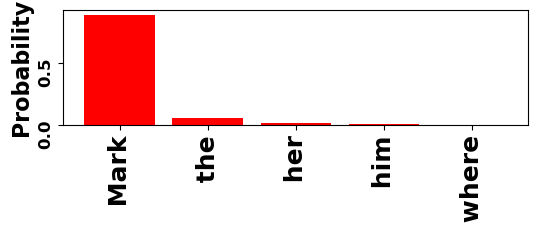

In [16]:
import torch
k = 5
logit_vector = logits_orig[-2].detach()             

# Compute softmax probabilities
probs = torch.softmax(logit_vector, dim=-1)

# Get top k probabilities and their indices
top_probs, top_indices = torch.topk(probs, k)
top_tokens = [tokenizer.decode([idx]) for idx in top_indices]

import matplotlib.pyplot as plt

plt.figure(figsize=(6,1.5), dpi=100)
bars = plt.bar(range(k), top_probs.cpu().numpy(), tick_label=top_tokens, color='red')
plt.xticks(rotation=90, fontweight='bold', fontsize=18)
# plt.xlabel('Token',rotation=180, fontweight='bold', fontsize=12)
plt.ylabel('Probability', fontweight='bold', fontsize=16,rotation=90)
plt.yticks(rotation=90, fontweight='bold', fontsize=12)
plt.gca().yaxis.set_major_locator(plt.MaxNLocator(nbins=2))  # increase number of ticks

# plt.title(f'Top {k} Tokens in Softmax of Logits')
plt.show()

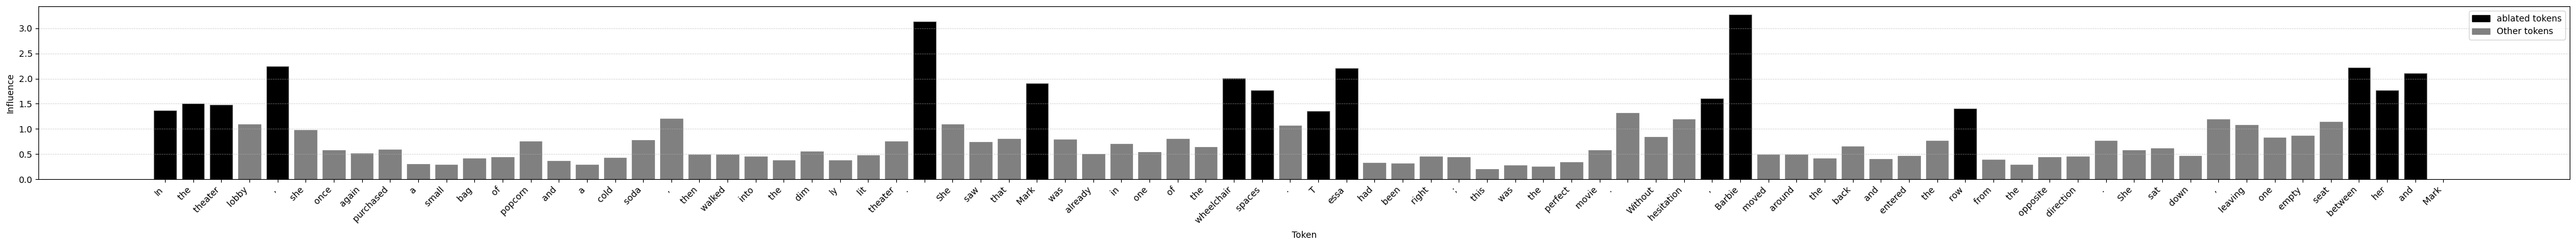

In [17]:


# Assign colors: gray for top tokens, blue otherwise
bar_colors = []
for i in range(len(grad_vals)):
    if i in ablated_indices:
        bar_colors.append('black')
    else:
        bar_colors.append('gray')

fig, ax = plt.subplots(figsize=(max(10, len(tick_label_text) * 0.5), 4))
ax.bar(range(len(tick_label_text)), grad_vals, color=bar_colors, edgecolor='gray', linewidth=0.5)
ax.set_xticks(range(len(tick_label_text)))
ax.set_xticklabels([t if t.strip() else '·' for t in tick_label_text], rotation=45, ha='right')
ax.set_xlabel('Token')
ax.set_ylabel('Influence')
ax.grid(True, which='both', axis='y', linestyle='--', linewidth=0.5, alpha=0.7)

legend_patches = [
    plt.matplotlib.patches.Patch(color='black', label=f'ablated tokens'),
    plt.matplotlib.patches.Patch(color='gray', label='Other tokens')
]
ax.legend(handles=legend_patches, loc='best')

plt.tight_layout()
plt.show()
